<a href="https://colab.research.google.com/github/ebuehrle/tennis-lines/blob/master/tennis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import cvxpy as cp
import itertools
import matplotlib.pyplot as plt
import numpy as np

In [8]:
b = 10.97
h = 11.89
s = 1.37
c = 6.4

In [9]:
V = np.array((
    (0, 0),   # 0 back left out
    (s, 0),   # 1 back left in
    (b-s, 0), # 2 back right in
    (b, 0),   # 3 back right out

    (b, h),   # 4 front right out
    (b-s, h), # 5 front right in
    (b/2, h), # 6 front center
    (s, h),   # 7 front left in
    (0, h),   # 8 front left out

    (s, h/2),   # 9  mid left
    (b/2, h/2), # 10 mid center
    (b-s, h/2), # 11 mid right
))

In [ ]:
L = np.array((
    (0, 8 ),  # left doubles sideline
    (1, 7 ),  # left singles sideline
    (2, 5 ),  # right singles sideline
    (3, 4 ),  # right doubles sideline
    (6, 10),  # center service line
    (9, 11),  # service line
    (0, 3 ),  # baseline
))

In [11]:
N = V.shape[0]

In [12]:
ce = np.linalg.norm(V[np.newaxis, :, :] - V[:, np.newaxis, :], axis=-1)
xv = cp.Variable((N, N, N), boolean=True)

In [13]:
p = cp.Problem(cp.Minimize(cp.multiply(ce[np.newaxis, :, :], xv).sum()), [
    xv.sum(axis=(1,2)) == 1,
    # xv.sum(axis=(0,2)) == 1,
    # xv.sum(axis=(0,1)) == 1,

    xv.sum(axis=2)[1:,:] == xv.sum(axis=1)[:-1,:],
    xv.sum(axis=2)[0,:]  == xv.sum(axis=1)[-1,:],

    xv.sum(axis=0)[L[:,0],L[:,1]] + xv.sum(axis=0)[L[:,1],L[:,0]] >= 1,
])

In [14]:
p.solve()

/usr/local/lib/python3.12/dist-packages/cvxpy/reductions/solvers/solving_chain_utils.py:30: UserWarning: The problem includes expressions that don't support CPP backend. Defaulting to the SCIPY backend for canonicalization.
  warnings.warn(UserWarning(


np.float64(95.85046333974122)

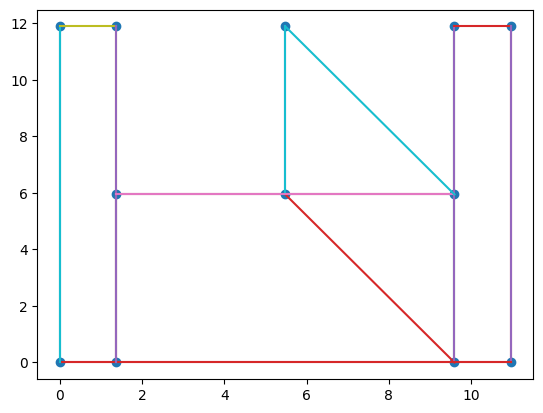

In [15]:
plt.figure()
plt.scatter(*np.array(V).T)
[plt.plot(*np.stack([V[i], V[k]], axis=0).T) for (i,k) in L]
[plt.plot(*np.stack([V[i,:], V[k,:]], axis=0).T, alpha=np.clip(xv.value, 0, 1)[t,i,k]) for t in range(N) for i in range(N) for k in range(N)]
plt.show()